# Unsupervised Anomaly Detection — Authentication Logs (v3)

This notebook applies **unsupervised** anomaly detection (K-Means and One-Class SVM) to the
RBA (Risk-Based Authentication) dataset.

## Strategy: Label-Guided Hyperparameter Selection

The dataset already has labels (`Is Account Takeover`). We exploit them in two ways:

1. **Threshold tuning (K-Means):** Instead of arbitrarily labelling the highest-distance
   cluster as anomalous, we use `y_train` to find the **optimal distance threshold**
   that maximises F1 on the train set, then apply it to the test set.
2. **Label-guided hyperparameter selection:** For both models, we sweep hyperparameters
   and pick the config that best balances **Accuracy + F1** on the train set.
   This is valid — we are not training a supervised model, just choosing which
   unsupervised configuration generalises best.

**Models:** K-Means (k sweep 2–10) · One-Class SVM (nu × gamma grid)

**Visualisation:** PCA · t-SNE

**Sampling:** 141 Takeover + 14,100 Normal (1 : 100 ratio)

# 1. Imports

In [23]:
import numpy as np
import pandas as pd
import ipaddress
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import StandardScaler, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.cluster            import MiniBatchKMeans
from sklearn.svm                import OneClassSVM
from sklearn.decomposition      import PCA
from sklearn.manifold           import TSNE
from sklearn.metrics            import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)
from scipy.sparse import issparse

SEED = 42
print('Libraries loaded.')

Libraries loaded.


# 2. Load & Preprocess Data

In [24]:
data = pd.read_csv('rba-dataset.csv')
print('Raw shape:', data.shape)

# Timestamp → hour
data['Login Hour'] = pd.to_datetime(data['Login Timestamp']).dt.hour

# Bool columns → uint8
for col in ['Is Account Takeover', 'Is Attack IP', 'Login Successful']:
    data[col] = data[col].astype(np.uint8)

# Drop unused columns
data.drop(columns=['Round-Trip Time [ms]', 'Region', 'City', 'Login Timestamp', 'index'],
          inplace=True)

# Factorize high-cardinality strings
for col in ['User Agent String', 'Browser Name and Version', 'OS Name and Version']:
    data[col], _ = pd.factorize(data[col])

# IP → integer
data['IP Address'] = data['IP Address'].apply(
    lambda ip: int(ipaddress.ip_address(ip))
)

print('Cleaned shape:', data.shape)
data.head(3)

Raw shape: (31269264, 16)
Cleaned shape: (31269264, 12)


,User ID,IP Address,Country,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover,Login Hour
0,-4324475583306591935,167788971,NO,29695,0,0,0,mobile,0,0,0,12
1,-4324475583306591935,3260534534,AU,60117,1,1,1,mobile,0,0,0,12
2,-3284137479262433373,1369935930,NO,29695,2,2,2,mobile,1,0,0,12


## 2.1 Undersample to 1 : 100 ratio

In [25]:
N_TAKEOVER, N_NORMAL = 141, 14_100

df = pd.concat([
    data[data['Is Account Takeover'] == 1],
    data[data['Is Account Takeover'] == 0].sample(n=N_NORMAL, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print('Sampled shape:', df.shape)
print(df['Is Account Takeover'].value_counts().rename({0:'Normal',1:'Takeover'}))

Sampled shape: (14241, 12)
Is Account Takeover
Normal      14100
Takeover      141
Name: count, dtype: int64


# 3. Features & Labels

In [26]:
NUM_COLS = ['ASN', 'Login Hour', 'IP Address',
            'User Agent String', 'Browser Name and Version', 'OS Name and Version']
CAT_COLS = ['Country', 'Device Type']

X = df[NUM_COLS + CAT_COLS]
y = df['Is Account Takeover']

print('X shape:', X.shape)
print(y.value_counts().rename({0:'Normal',1:'Takeover'}))

X shape: (14241, 8)
Is Account Takeover
Normal      14100
Takeover      141
Name: count, dtype: int64


# 4. Train / Test Split + Preprocessing

`y_train` is kept alongside `X_train` and will be used to:
- Guide threshold selection for K-Means
- Select the best hyperparameters for both models

Neither model receives `y_train` inside `.fit()` — they remain unsupervised.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Takeover rate — train: {y_train.mean():.4%}  |  test: {y_test.mean():.4%}')
print('\nTrain labels:')
print(y_train.value_counts().rename({0:'Normal',1:'Takeover'}))
print('\nTest labels:')
print(y_test.value_counts().rename({0:'Normal',1:'Takeover'}))

Train: 11,392  |  Test: 2,849
Takeover rate — train: 0.9919%  |  test: 0.9828%

Train labels:
Is Account Takeover
Normal      11279
Takeover      113
Name: count, dtype: int64

Test labels:
Is Account Takeover
Normal      2821
Takeover      28
Name: count, dtype: int64


In [28]:
def make_preprocessor():
    return ColumnTransformer([
        ('num', StandardScaler(),                         NUM_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore'),   CAT_COLS)
    ])

pre          = make_preprocessor()
X_train_sp   = pre.fit_transform(X_train)   # sparse
X_test_sp    = pre.transform(X_test)

# Dense — needed by OCSVM, PCA, t-SNE
to_dense     = lambda m: m.toarray() if issparse(m) else m
X_train_dn   = to_dense(X_train_sp)
X_test_dn    = to_dense(X_test_sp)

print('Train processed:', X_train_dn.shape)
print('Test  processed:', X_test_dn.shape)

Train processed: (11392, 107)
Test  processed: (2849, 107)


# 5. Shared Utilities

In [29]:
def combined_score(acc, f1, alpha=0.5):
    """Weighted combination used to select best hyperparameters.
    alpha=0.5 means equal weight on Accuracy and F1."""
    return alpha * acc + (1 - alpha) * f1


def evaluate(name, split, y_true, y_pred, scores):
    """Print full metrics report and return summary dict."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, scores)

    print(f'\n{"="*60}')
    print(f'  {name}  |  {split} set')
    print(f'{"="*60}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-score  : {f1:.4f}')
    print(f'  ROC AUC   : {auc:.4f}')
    print(f'  Combined  : {combined_score(acc, f1):.4f}  (0.5·Acc + 0.5·F1)')
    print('\n  Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))
    print()
    print(classification_report(y_true, y_pred,
                                target_names=['Normal','Takeover'],
                                zero_division=0))
    return dict(Model=name, Split=split,
                Accuracy=round(acc,4), Precision=round(prec,4),
                Recall=round(rec,4), F1=round(f1,4), ROC_AUC=round(auc,4),
                Combined=round(combined_score(acc,f1),4))


def best_threshold_f1(scores, y_true, n_thresh=300):
    """Sweep thresholds and return the one maximising F1 on y_true."""
    thresholds = np.linspace(scores.min(), scores.max(), n_thresh)
    best_t, best_f1 = 0.0, 0.0
    for t in thresholds:
        preds = (scores >= t).astype(int)
        f = f1_score(y_true, preds, zero_division=0)
        if f > best_f1:
            best_f1 = f
            best_t  = t
    return best_t, best_f1


print('Utilities ready.')

Utilities ready.


# 6. PCA Visualisation

Reduce to 2 components and colour by true label to inspect linear separability.

PC1 variance: 0.3005  |  PC2 variance: 0.1814  |  Total: 0.4819


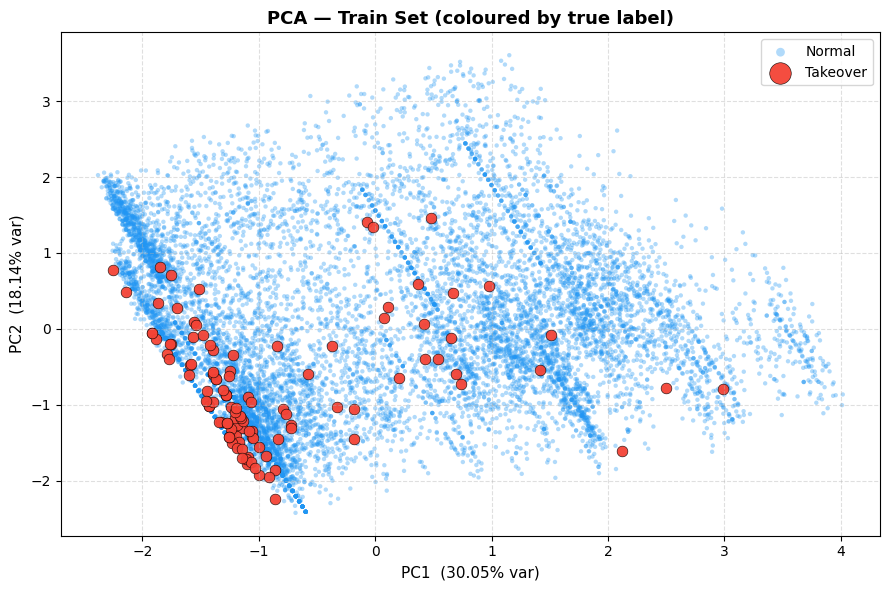

In [30]:
pca      = PCA(n_components=2, random_state=SEED)
X_pca    = pca.fit_transform(X_train_dn)
ev       = pca.explained_variance_ratio_

print(f'PC1 variance: {ev[0]:.4f}  |  PC2 variance: {ev[1]:.4f}  |  Total: {ev.sum():.4f}')

fig, ax = plt.subplots(figsize=(9, 6))
for cls, (label, color, size, alpha) in enumerate(
        [("Normal", "#2196F3", 10, 0.35), ("Takeover", "#F44336", 60, 0.95)]):
    mask = y_train.values == cls
    ax.scatter(X_pca[mask,0], X_pca[mask,1],
               c=color, s=size, alpha=alpha, label=label,
               edgecolors='k' if cls==1 else 'none', linewidths=0.4)

ax.set_xlabel(f'PC1  ({ev[0]:.2%} var)', fontsize=11)
ax.set_ylabel(f'PC2  ({ev[1]:.2%} var)', fontsize=11)
ax.set_title('PCA — Train Set (coloured by true label)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, markerscale=2)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('pca_true_labels.png', dpi=150)
plt.show()

# 7. t-SNE Visualisation

Non-linear embedding. Subsampled to 3,000 rows (all Takeover kept) for speed.

In [31]:
TSNE_MAX     = 3000
rng          = np.random.default_rng(SEED)
tak_idx      = np.where(y_train.values == 1)[0]
nor_idx      = np.where(y_train.values == 0)[0]
nor_sampled  = rng.choice(nor_idx, size=min(TSNE_MAX - len(tak_idx), len(nor_idx)), replace=False)
tsne_idx     = np.concatenate([tak_idx, nor_sampled])

print(f't-SNE input: {len(tsne_idx):,} rows ({len(tak_idx)} Takeover + {len(nor_sampled):,} Normal)')
print('Running t-SNE … (~1–2 min)')

tsne  = TSNE(n_components=2, perplexity=30, max_iter=1000,
             learning_rate='auto', random_state=SEED)
X_2d  = tsne.fit_transform(X_train_dn[tsne_idx])
y_2d  = y_train.values[tsne_idx]
print('Done.')

t-SNE input: 3,000 rows (113 Takeover + 2,887 Normal)
Running t-SNE … (~1–2 min)
Done.


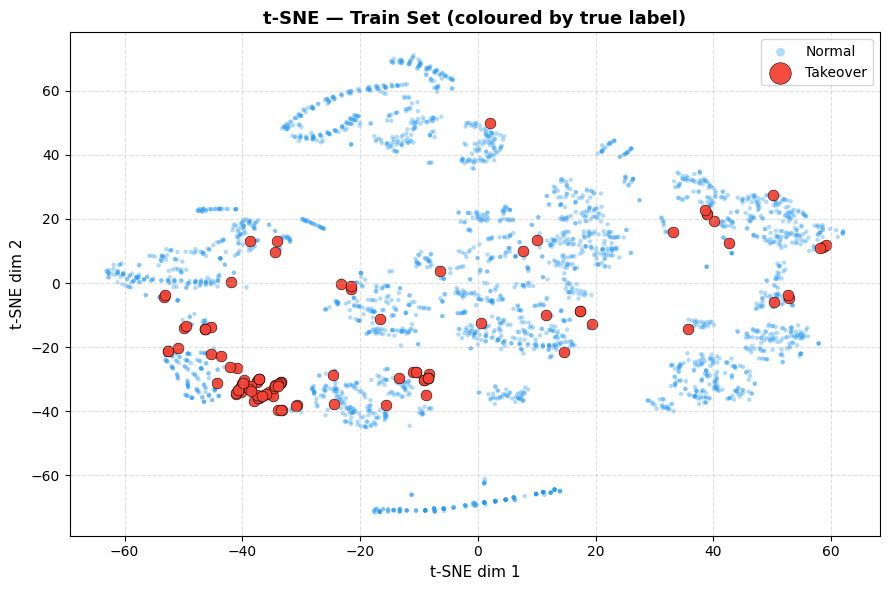

In [32]:
fig, ax = plt.subplots(figsize=(9, 6))
for cls, (label, color, size, alpha) in enumerate(
        [("Normal", "#2196F3", 10, 0.35), ("Takeover", "#F44336", 60, 0.95)]):
    mask = y_2d == cls
    ax.scatter(X_2d[mask,0], X_2d[mask,1],
               c=color, s=size, alpha=alpha, label=label,
               edgecolors='k' if cls==1 else 'none', linewidths=0.4)

ax.set_xlabel('t-SNE dim 1', fontsize=11)
ax.set_ylabel('t-SNE dim 2', fontsize=11)
ax.set_title('t-SNE — Train Set (coloured by true label)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, markerscale=2)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('tsne_true_labels.png', dpi=150)
plt.show()

# 8. K-Means — Label-Guided Hyperparameter Search

**What we tune:**
- `k` (number of clusters): sweep 2 → 10
- `batch_size`: [512, 1000, 2048]

**How labels are used:**
After fitting (unsupervised), we compute anomaly scores (distance-to-centroid) on the
**train set** and use `y_train` to find the **optimal decision threshold** that maximises
F1. The best `(k, batch_size, threshold)` combo is picked by highest
`combined_score = 0.5·Accuracy + 0.5·F1` on train, then applied unchanged to the test set.

In [33]:
def kmeans_scores(X_sp, model):
    """Return per-point distance to assigned centroid (higher = more anomalous)."""
    cl   = model.predict(X_sp)
    dist = model.transform(X_sp)                      # (n, k)
    return dist[np.arange(len(cl)), cl], cl


km_grid    = []
k_values   = list(range(2, 11))          # 2 … 10
batch_sizes = [512, 1000, 2048]

header = f'{"k":>3}  {"batch":>6}  {"thresh":>8}  {"Acc":>7}  {"F1":>7}  {"AUC":>7}  {"Combined":>9}'
print(header)
print('-' * len(header))

for k in k_values:
    for bs in batch_sizes:
        km = MiniBatchKMeans(n_clusters=k, batch_size=bs,
                             n_init='auto', random_state=SEED)
        km.fit(X_train_sp)                             # ← no labels

        tr_scores, _ = kmeans_scores(X_train_sp, km)
        threshold, _ = best_threshold_f1(tr_scores, y_train)  # ← labels used HERE

        tr_preds = (tr_scores >= threshold).astype(int)
        acc  = accuracy_score(y_train, tr_preds)
        f1   = f1_score(y_train, tr_preds, zero_division=0)
        auc  = roc_auc_score(y_train, tr_scores)
        comb = combined_score(acc, f1)

        km_grid.append(dict(k=k, batch_size=bs, threshold=threshold,
                            acc=acc, f1=f1, auc=auc, combined=comb,
                            model=km))
        print(f'{k:>3}  {bs:>6}  {threshold:>8.4f}  {acc:>7.4f}  {f1:>7.4f}  {auc:>7.4f}  {comb:>9.4f}')

best_km_cfg = max(km_grid, key=lambda x: x['combined'])
print(f'\n>>> Best K-Means: k={best_km_cfg["k"]}, batch={best_km_cfg["batch_size"]},'
      f' threshold={best_km_cfg["threshold"]:.4f}  (Combined={best_km_cfg["combined"]:.4f})')

  k   batch    thresh      Acc       F1      AUC   Combined
-----------------------------------------------------------
  2     512    1.7239   0.1328   0.0220   0.5085     0.0774
  2    1000    1.7091   0.1215   0.0219   0.5095     0.0717
  2    2048    1.7268   0.1342   0.0220   0.5081     0.0781
  3     512    2.4778   0.7805   0.0250   0.5805     0.4027
  3    1000    2.0921   0.5376   0.0234   0.5449     0.2805
  3    2048    2.8259   0.9194   0.0255   0.5823     0.4724
  4     512    2.2160   0.7233   0.0308   0.6217     0.3770
  4    1000    1.6772   0.3232   0.0231   0.5413     0.1731
  4    2048    2.8319   0.9494   0.0335   0.6127     0.4914
  5     512    2.2033   0.7618   0.0335   0.6593     0.3976
  5    1000    2.0210   0.6717   0.0281   0.6140     0.3499
  5    2048    2.5281   0.9066   0.0345   0.6132     0.4705
  6     512    2.1679   0.7875   0.0343   0.6761     0.4109
  6    1000    2.6427   0.9393   0.0336   0.6510     0.4865
  6    2048    2.6827   0.9521   0.0353 

## 8.1 K-Means Search — Visualisation

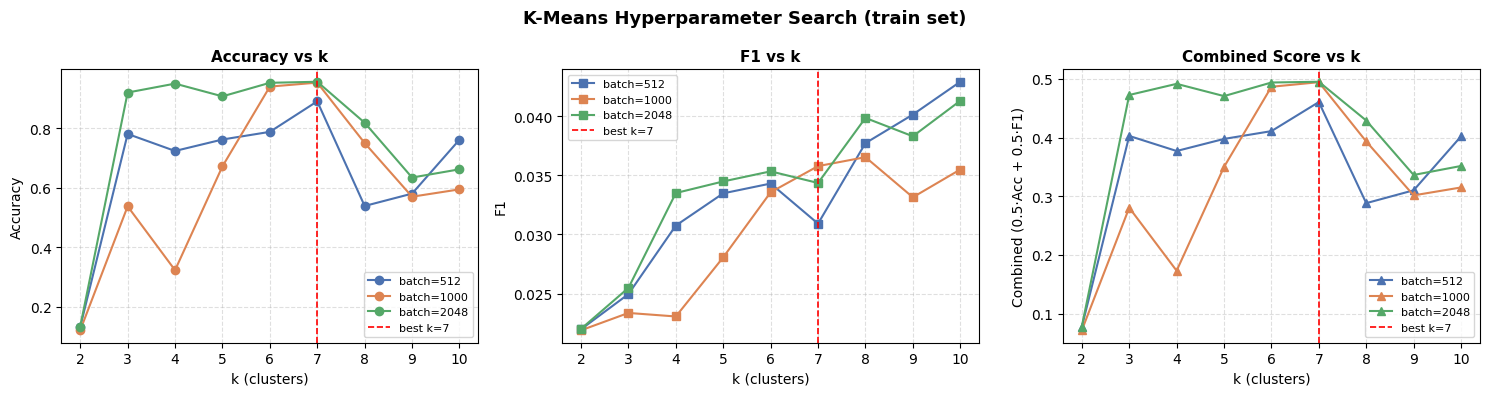

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors_bs = {512: '#4C72B0', 1000: '#DD8452', 2048: '#55A868'}

for bs in batch_sizes:
    subset = [r for r in km_grid if r['batch_size'] == bs]
    ks     = [r['k'] for r in subset]
    axes[0].plot(ks, [r['acc']      for r in subset], 'o-', label=f'batch={bs}', color=colors_bs[bs])
    axes[1].plot(ks, [r['f1']       for r in subset], 's-', label=f'batch={bs}', color=colors_bs[bs])
    axes[2].plot(ks, [r['combined'] for r in subset], '^-', label=f'batch={bs}', color=colors_bs[bs])

for ax, title, ylabel in zip(axes,
    ['Accuracy vs k', 'F1 vs k', 'Combined Score vs k'],
    ['Accuracy', 'F1', 'Combined (0.5·Acc + 0.5·F1)']):
    ax.axvline(best_km_cfg['k'], color='red', linestyle='--', linewidth=1.2, label=f'best k={best_km_cfg["k"]}')
    ax.set_xlabel('k (clusters)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('K-Means Hyperparameter Search (train set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_search.png', dpi=150)
plt.show()

# 9. One-Class SVM — Label-Guided Hyperparameter Search

**What we tune:**
- `nu`: [0.005, 0.01, 0.03, 0.05, 0.10, 0.15]
- `gamma`: ['scale', 'auto', 0.001, 0.005, 0.01, 0.05]

**How labels are used:**
Same strategy — fit unsupervised, then use `y_train` + threshold sweep to find the
best decision boundary offset. Best config = highest Combined score on train.

In [35]:
NU_VALUES    = [0.005, 0.01, 0.03, 0.05, 0.10, 0.15]
GAMMA_VALUES = ['scale', 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]

oc_grid     = []
auc_matrix  = np.zeros((len(NU_VALUES), len(GAMMA_VALUES)))
comb_matrix = np.zeros_like(auc_matrix)

header = f'{"nu":>6}  {"gamma":>6}  {"thresh":>8}  {"Acc":>7}  {"F1":>7}  {"AUC":>7}  {"Combined":>9}'
print(header)
print('-' * len(header))

for i, nu in enumerate(NU_VALUES):
    for j, gamma in enumerate(GAMMA_VALUES):
        oc = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        oc.fit(X_train_dn)                              # ← no labels

        tr_raw    = -oc.decision_function(X_train_dn)   # negate: higher = more anomalous
        threshold, _ = best_threshold_f1(tr_raw, y_train)  # ← labels used HERE

        tr_preds  = (tr_raw >= threshold).astype(int)
        acc  = accuracy_score(y_train, tr_preds)
        f1   = f1_score(y_train, tr_preds, zero_division=0)
        auc  = roc_auc_score(y_train, tr_raw)
        comb = combined_score(acc, f1)

        auc_matrix[i, j]  = auc
        comb_matrix[i, j] = comb

        oc_grid.append(dict(nu=nu, gamma=str(gamma), threshold=threshold,
                            acc=acc, f1=f1, auc=auc, combined=comb,
                            model=oc))
        print(f'{nu:>6}  {str(gamma):>6}  {threshold:>8.4f}  {acc:>7.4f}  {f1:>7.4f}  {auc:>7.4f}  {comb:>9.4f}')

best_oc_cfg = max(oc_grid, key=lambda x: x['combined'])
print(f'\n>>> Best OCSVM: nu={best_oc_cfg["nu"]}, gamma={best_oc_cfg["gamma"]},'
      f' threshold={best_oc_cfg["threshold"]:.4f}  (Combined={best_oc_cfg["combined"]:.4f})')

    nu   gamma    thresh      Acc       F1      AUC   Combined
--------------------------------------------------------------
 0.005   scale   -0.1135   0.9740   0.0633   0.6704     0.5187
 0.005  0.0001   -0.0104   0.9347   0.0653   0.6736     0.5000
 0.005  0.0005   -0.0163   0.9758   0.0676   0.6747     0.5217
 0.005   0.001   -0.0976   0.9361   0.0667   0.6751     0.5014
 0.005   0.005   -0.4271   0.9366   0.0672   0.6749     0.5019
 0.005    0.01   -0.7648   0.9291   0.0605   0.6710     0.4948
 0.005    0.05   -1.2373   0.9199   0.0519   0.6471     0.4859
 0.005     0.1   -0.5752   0.9293   0.0541   0.6615     0.4917
  0.01   scale   -0.5151   0.9513   0.0641   0.6624     0.5077
  0.01  0.0001   -0.0156   0.9362   0.0668   0.6813     0.5015
  0.01  0.0005   -0.0105   0.9755   0.0669   0.6807     0.5212
  0.01   0.001   -0.1498   0.9378   0.0683   0.6806     0.5030
  0.01   0.005   -0.6552   0.9368   0.0674   0.6774     0.5021
  0.01    0.01   -1.0984   0.9386   0.0692   0.6741    

In [36]:
gamma_scale_value = 1 / (X_train_dn.shape[1] * X_train_dn.var())
print(f"gamma='scale' resolves to: {gamma_scale_value:.6f}")

gamma='scale' resolves to: 0.125587


## 9.1 OCSVM Search — Heatmaps

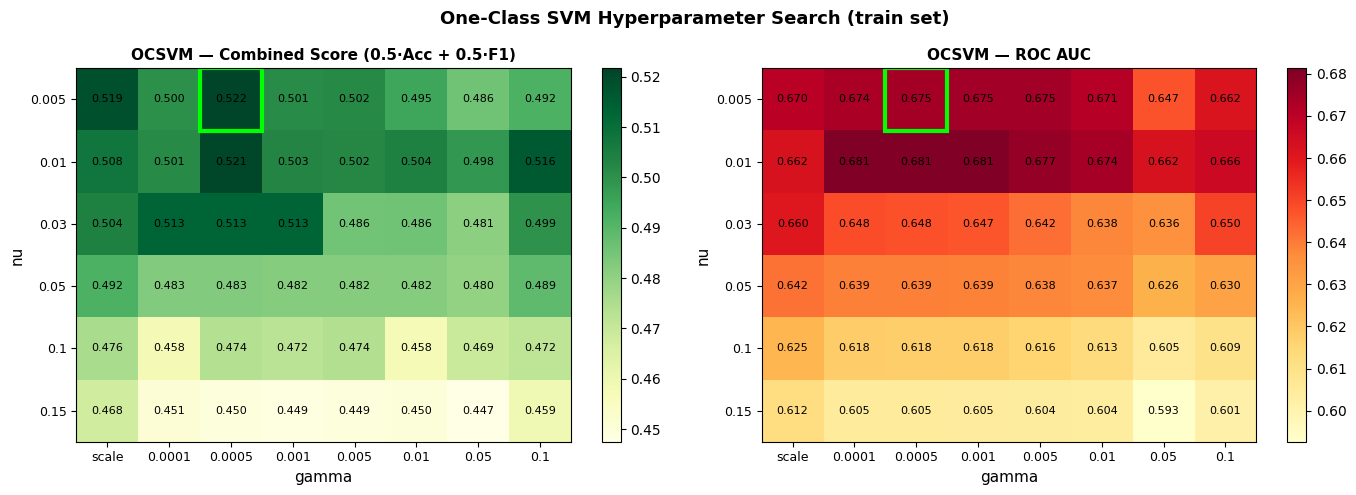

In [37]:
gamma_labels = [str(g) for g in GAMMA_VALUES]
nu_labels    = [str(n) for n in NU_VALUES]

best_i = NU_VALUES.index(best_oc_cfg['nu'])
best_j = gamma_labels.index(best_oc_cfg['gamma'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, matrix, title, cmap in zip(
        axes,
        [comb_matrix, auc_matrix],
        ['Combined Score (0.5·Acc + 0.5·F1)', 'ROC AUC'],
        ['YlGn', 'YlOrRd']):

    im = ax.imshow(matrix, cmap=cmap, aspect='auto',
                   vmin=matrix.min(), vmax=matrix.max())
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(GAMMA_VALUES)))
    ax.set_xticklabels(gamma_labels, fontsize=9)
    ax.set_yticks(range(len(NU_VALUES)))
    ax.set_yticklabels(nu_labels, fontsize=9)
    ax.set_xlabel('gamma', fontsize=11)
    ax.set_ylabel('nu', fontsize=11)
    ax.set_title(f'OCSVM — {title}', fontsize=11, fontweight='bold')

    for r in range(len(NU_VALUES)):
        for c in range(len(GAMMA_VALUES)):
            ax.text(c, r, f'{matrix[r,c]:.3f}', ha='center', va='center', fontsize=8)

    ax.add_patch(plt.Rectangle((best_j-.5, best_i-.5), 1, 1,
                               fill=False, edgecolor='lime', linewidth=3))

plt.suptitle('One-Class SVM Hyperparameter Search (train set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ocsvm_search.png', dpi=150)
plt.show()

# 10. Final Evaluation — Best Configurations

Apply the best `(k, threshold)` and `(nu, gamma, threshold)` — found on train — to the **test set**.
The threshold is applied as-is; no re-fitting or re-tuning on test data.

In [38]:
print('=== Best configurations ===')
print(f'K-Means : k={best_km_cfg["k"]}, batch_size={best_km_cfg["batch_size"]}, threshold={best_km_cfg["threshold"]:.4f}')
print(f'OCSVM   : nu={best_oc_cfg["nu"]}, gamma={best_oc_cfg["gamma"]}, threshold={best_oc_cfg["threshold"]:.4f}')

=== Best configurations ===
K-Means : k=7, batch_size=2048, threshold=2.6747
OCSVM   : nu=0.005, gamma=0.0005, threshold=-0.0163


In [39]:
# ── K-Means final ──────────────────────────────────────────────
km_best     = best_km_cfg['model']
km_thr      = best_km_cfg['threshold']

km_tr_sc, _ = kmeans_scores(X_train_sp, km_best)
km_te_sc, _ = kmeans_scores(X_test_sp,  km_best)

km_tr_pred  = (km_tr_sc >= km_thr).astype(int)
km_te_pred  = (km_te_sc >= km_thr).astype(int)

km_name = f'K-Means (k={best_km_cfg["k"]}, bs={best_km_cfg["batch_size"]})'

rows = []
rows.append(evaluate(km_name, 'Train', y_train, km_tr_pred, km_tr_sc))
rows.append(evaluate(km_name, 'Test',  y_test,  km_te_pred, km_te_sc))


  K-Means (k=7, bs=2048)  |  Train set
  Accuracy  : 0.9556
  Precision : 0.0219
  Recall    : 0.0796
  F1-score  : 0.0344
  ROC AUC   : 0.6542
  Combined  : 0.4950  (0.5·Acc + 0.5·F1)

  Confusion Matrix:
[[10877   402]
 [  104     9]]

              precision    recall  f1-score   support

      Normal       0.99      0.96      0.98     11279
    Takeover       0.02      0.08      0.03       113

    accuracy                           0.96     11392
   macro avg       0.51      0.52      0.51     11392
weighted avg       0.98      0.96      0.97     11392


  K-Means (k=7, bs=2048)  |  Test set
  Accuracy  : 0.9568
  Precision : 0.0103
  Recall    : 0.0357
  F1-score  : 0.0160
  ROC AUC   : 0.7152
  Combined  : 0.4864  (0.5·Acc + 0.5·F1)

  Confusion Matrix:
[[2725   96]
 [  27    1]]

              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98      2821
    Takeover       0.01      0.04      0.02        28

    accuracy                        

In [40]:
# ── One-Class SVM final ────────────────────────────────────────
oc_best    = best_oc_cfg['model']
oc_thr     = best_oc_cfg['threshold']

oc_tr_sc   = -oc_best.decision_function(X_train_dn)
oc_te_sc   = -oc_best.decision_function(X_test_dn)

oc_tr_pred = (oc_tr_sc >= oc_thr).astype(int)
oc_te_pred = (oc_te_sc >= oc_thr).astype(int)

oc_name = f'OCSVM (nu={best_oc_cfg["nu"]}, γ={best_oc_cfg["gamma"]})'

rows.append(evaluate(oc_name, 'Train', y_train, oc_tr_pred, oc_tr_sc))
rows.append(evaluate(oc_name, 'Test',  y_test,  oc_te_pred, oc_te_sc))


  OCSVM (nu=0.005, γ=0.0005)  |  Train set
  Accuracy  : 0.9758
  Precision : 0.0546
  Recall    : 0.0885
  F1-score  : 0.0676
  ROC AUC   : 0.6747
  Combined  : 0.5217  (0.5·Acc + 0.5·F1)

  Confusion Matrix:
[[11106   173]
 [  103    10]]

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99     11279
    Takeover       0.05      0.09      0.07       113

    accuracy                           0.98     11392
   macro avg       0.52      0.54      0.53     11392
weighted avg       0.98      0.98      0.98     11392


  OCSVM (nu=0.005, γ=0.0005)  |  Test set
  Accuracy  : 0.9779
  Precision : 0.0930
  Recall    : 0.1429
  F1-score  : 0.1127
  ROC AUC   : 0.6926
  Combined  : 0.5453  (0.5·Acc + 0.5·F1)

  Confusion Matrix:
[[2782   39]
 [  24    4]]

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      2821
    Takeover       0.09      0.14      0.11        28

    accuracy                

# 11. Summary Table

In [41]:
summary = pd.DataFrame(rows).set_index(['Model', 'Split'])
print(summary.to_string())

                                  Accuracy  Precision  Recall      F1  ROC_AUC  Combined
Model                      Split                                                        
K-Means (k=7, bs=2048)     Train    0.9556     0.0219  0.0796  0.0344   0.6542    0.4950
                           Test     0.9568     0.0103  0.0357  0.0160   0.7152    0.4864
OCSVM (nu=0.005, γ=0.0005) Train    0.9758     0.0546  0.0885  0.0676   0.6747    0.5217
                           Test     0.9779     0.0930  0.1429  0.1127   0.6926    0.5453


# 12. Visualisations — Test Set

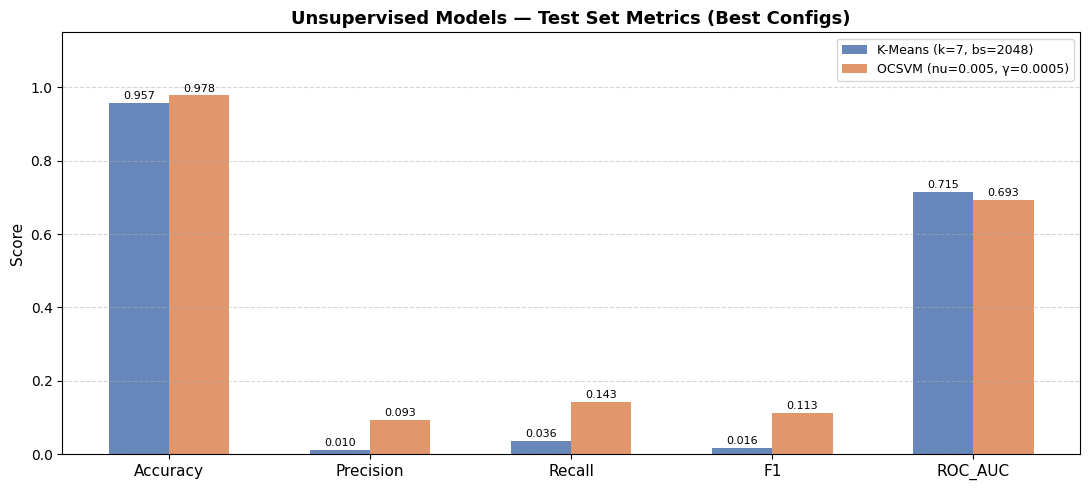

In [42]:
# ── Bar chart: test metrics ────────────────────────────────────
test_df  = summary.xs('Test', level='Split')
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
x        = np.arange(len(metrics))
width    = 0.30
pal      = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (model_name, row) in enumerate(test_df.iterrows()):
    offset = (i - 0.5) * width
    bars   = ax.bar(x + offset, row[metrics], width, label=model_name,
                    color=pal[i], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Unsupervised Models — Test Set Metrics (Best Configs)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('test_metrics_bar.png', dpi=150)
plt.show()

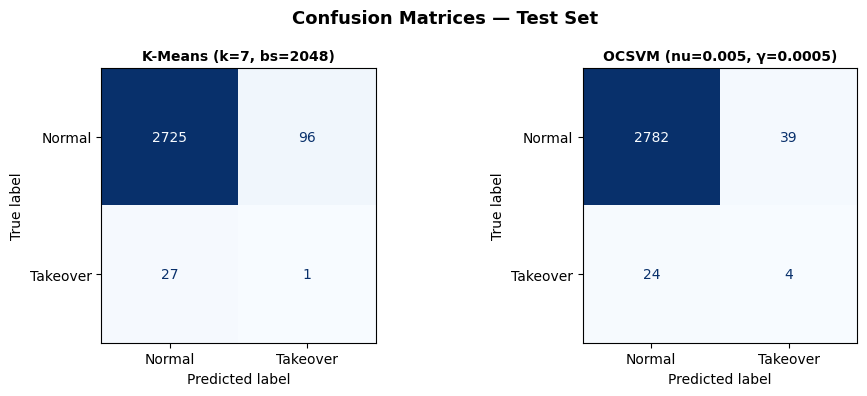

In [43]:
# ── Confusion matrices: test set ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, preds) in zip(axes, [(km_name, km_te_pred), (oc_name, oc_te_pred)]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, preds),
        display_labels=['Normal', 'Takeover']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_test.png', dpi=150)
plt.show()

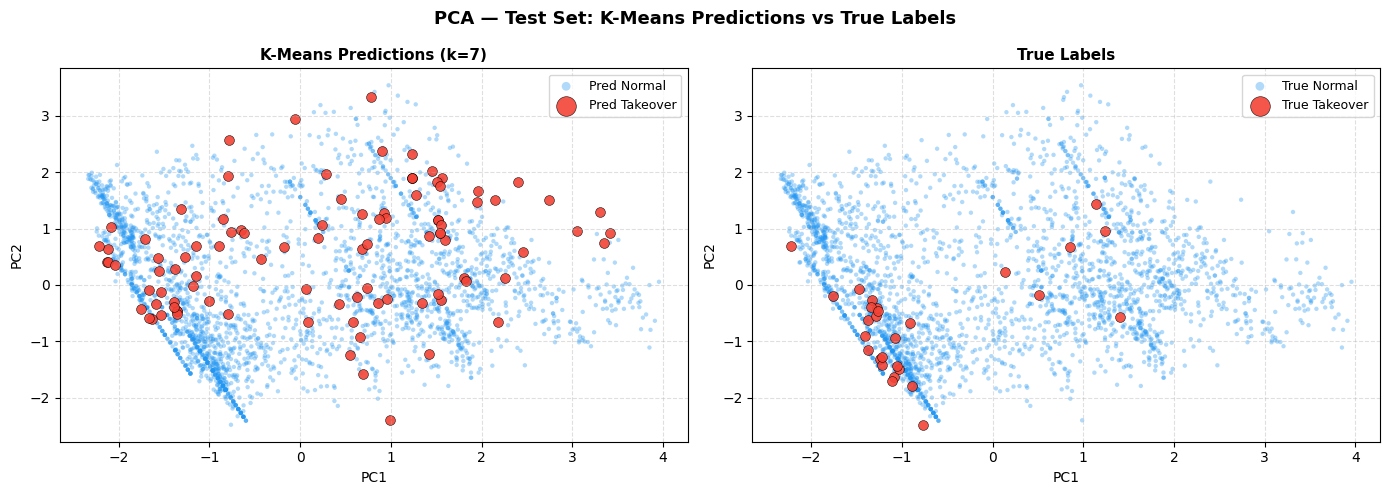

In [44]:
# ── PCA: predicted labels vs true labels (K-Means) ────────────
X_test_pca = pca.transform(X_test_dn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

titles = [f'K-Means Predictions (k={best_km_cfg["k"]})', 'True Labels']
label_sets = [
    (km_te_pred, {0: 'Pred Normal', 1: 'Pred Takeover'}),
    (y_test.values, {0: 'True Normal', 1: 'True Takeover'})
]

for ax, title, (lbls, lmap) in zip(axes, titles, label_sets):
    for cls, (color, size, alpha) in {0: ('#2196F3', 10, 0.35), 1: ('#F44336', 50, 0.9)}.items():
        mask = lbls == cls
        ax.scatter(X_test_pca[mask,0], X_test_pca[mask,1],
                   c=color, s=size, alpha=alpha, label=lmap[cls],
                   edgecolors='k' if cls==1 else 'none', linewidths=0.4)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=10); ax.set_ylabel('PC2', fontsize=10)
    ax.legend(fontsize=9, markerscale=2)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('PCA — Test Set: K-Means Predictions vs True Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_pred_vs_true_test.png', dpi=150)
plt.show()